In [6]:
!pip install simpy scikit-learn pandas numpy matplotlib seaborn tqdm

In [25]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
def request(env, name, servers, service_time, queue_limit, wait_times, dropped_requests):
    arrival_time = env.now

    if len(servers.queue) >= queue_limit:
        dropped_requests.append(1)
        return

    with servers.request() as req:
        yield req
        wait = env.now - arrival_time
        wait_times.append(wait)

        yield env.timeout(random.expovariate(1.0 / service_time))

In [27]:
def run_simulation(arrival_rate, num_servers, service_time, simulation_time, queue_limit=50):
    env = simpy.Environment()
    servers = simpy.Resource(env, capacity=num_servers)
    wait_times = []
    dropped_requests = []

    def request_generator(env):
        while True:
            yield env.timeout(random.expovariate(arrival_rate))
            env.process(request(env, "req", servers, service_time, queue_limit, wait_times, dropped_requests))

    env.process(request_generator(env))
    env.run(until=simulation_time)

    if wait_times:
        avg_wait = np.mean(wait_times)
    else:
        avg_wait = 0

    avg_response = avg_wait + service_time
    total_served = len(wait_times)
    total_dropped = len(dropped_requests)

    return {
        "arrival_rate": arrival_rate,
        "num_servers": num_servers,
        "service_time": service_time,
        "simulation_time": simulation_time,
        "queue_limit": queue_limit,
        "avg_response_time": avg_response,
        "requests_served": total_served,
        "dropped_requests": total_dropped
    }

In [36]:
random.seed(42)
np.random.seed(42)

# Define medium-scale ranges
ranges = {
    "arrival_rate": (1.0, 6.0),      # req/sec
    "service_time": (0.1, 0.8),       # seconds
    "num_servers": (3,10),           # parallel servers
    "queue_limit": (10,50),         # queued requests
    "simulation_time": (800,2000)
}

results = []

for _ in tqdm(range(1000)):
    arrival_rate = random.uniform(*ranges["arrival_rate"])
    service_time = random.uniform(*ranges["service_time"])
    num_servers = random.randint(*ranges["num_servers"])
    queue_limit = random.randint(*ranges["queue_limit"])
    simulation_time = random.randint(*ranges["simulation_time"])

    res = run_simulation(arrival_rate, num_servers, service_time, simulation_time, queue_limit)

    # Derived features
    res["load_intensity"] = (arrival_rate * service_time) / max(1, num_servers)
    res["drop_rate"] = res["dropped_requests"] / max(1, res["requests_served"] + res["dropped_requests"])

    results.append(res)

df = pd.DataFrame(results)
df.to_csv("cloud_server_medium.csv", index=False)
df.head()

100%|██████████| 1000/1000 [01:13<00:00, 13.57it/s]


,arrival_rate,num_servers,service_time,simulation_time,queue_limit,avg_response_time,requests_served,dropped_requests,load_intensity,drop_rate
0,4.197134,7,0.117508,1257,25,0.117508,5334,0,0.070456,0.0
1,2.588440,10,0.225458,811,14,0.225458,2040,0,0.058358,0.0
2,4.441287,3,0.126279,1289,28,0.127235,5909,0,0.186947,0.0
3,3.383331,8,0.753967,840,25,0.756389,2876,0,0.318865,0.0
4,1.193496,3,0.645738,844,27,0.652421,1028,0,0.256895,0.0


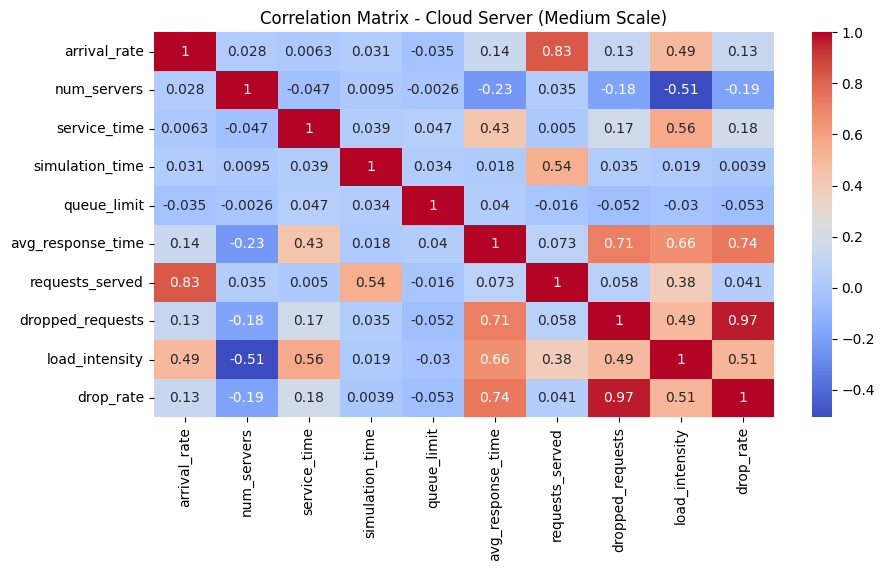

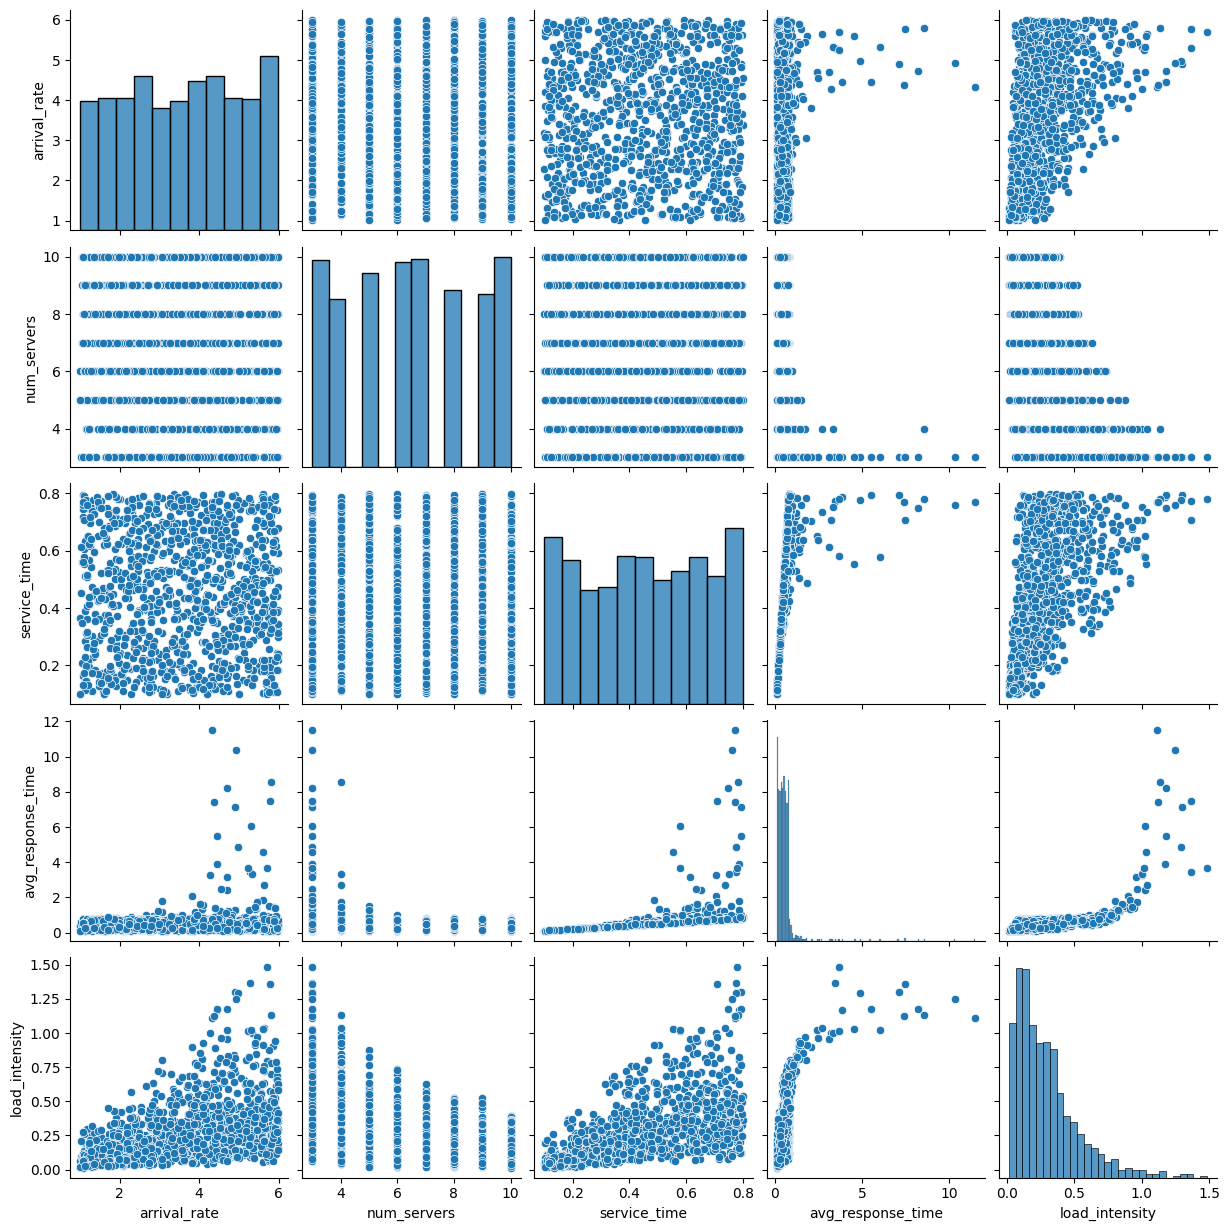

In [37]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Cloud Server (Medium Scale)")
plt.show()

sns.pairplot(df[["arrival_rate","num_servers","service_time","avg_response_time","load_intensity"]])
plt.show()

In [38]:
X = df[["arrival_rate","num_servers","service_time","simulation_time","queue_limit","load_intensity","drop_rate"]]
y = df["avg_response_time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
!pip install xgboost

In [45]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=100),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=5, subsample=0.8)
}

results_ml = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results_ml.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results_ml)
results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
4,XGBoost,0.018342,0.087974,0.962010
2,RandomForest,0.023236,0.125999,0.922072
3,GradientBoosting,0.028638,0.144991,0.896809
0,LinearRegression,0.143339,0.247398,0.699564
1,Ridge,0.211723,0.299538,0.559581


/tmp/ipython-input-3832095499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=results_df.sort_values("R2", ascending=False), palette="magma")


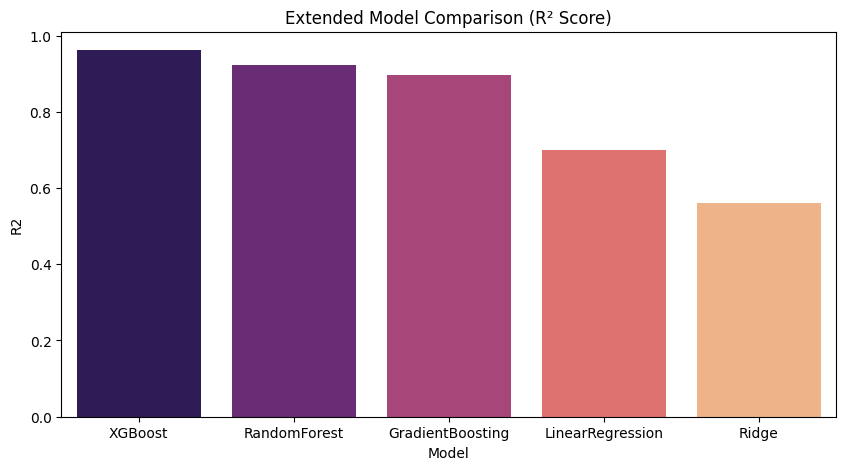

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="R2", data=results_df.sort_values("R2", ascending=False), palette="magma")
plt.title("Extended Model Comparison (R² Score)")
plt.show()

In [47]:
df.to_csv("cloud_server_sim_data_medium.csv", index=False)
results_df.to_csv("ml_results_medium.csv", index=False)